# 02 — Chứng minh đúng: kết luận chính có đứng vững không?

Notebook này gom **mọi phép thử độ tin cậy** của đồ án vào một chỗ. Nó không đưa ra kết luận mới — nó
cố **bẻ gãy** kết luận chính bằng mọi cách nhóm nghĩ ra, và ghi lại kết quả.

> **Kết luận chính (FINDINGS §4):** nhãn "giao trễ/đúng hẹn" do **khách tự báo** phân biệt mức hài lòng
> tốt hơn **chỉ báo SLA** (giao > 5 ngày) — chênh lệch **+0,208 điểm rating, KTC 95% [0,097 · 0,353]**.

| § | Câu hỏi phản biện | Tầng của khung "chứng minh đúng" |
|---|---|---|
| 1 | Con số +0,208 được tính thế nào? | 5 · Significance (bootstrap theo cụm) |
| 2 | Chạy lại trên dữ liệu cũ có ra đúng số đã công bố không? | 2 · Reproducibility |
| 3 | Sửa múi giờ có phải "chỉnh số cho đẹp" không? | 1 · Data contract · 9 · Sanity check |
| 4 | Ngưỡng 5 ngày là tuỳ tiện — đổi ngưỡng thì sao? | 8 · Robustness |
| 5 | Năm 2021 (giãn cách) có bóp méo kết luận không? | 8 · Robustness |
| 6 | 74% review không có nhãn — nếu nhóm đó khác hẳn thì sao? | MNAR · 8 |
| 7 | Bẫy SLA có khác nhau giữa ngành / nhà bán không? | 7 · Error analysis |
| 8 | Loại 1.799 dòng lỗi có cắt mất khách bất mãn không? | 1 · 8 |

Toàn bộ notebook chạy ~2 phút trên laptop. Mọi hình được lưu vào `reports/figures/A0*.png` để dùng trong slide.

In [1]:
from pathlib import Path
import os
import sys
import warnings

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)  # module trong src/ đọc đường dẫn tương đối tính từ gốc repo (data/, docs/)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.viz.theme import setup_theme, save_fig, PALETTE
from src.evaluate.stats import (cluster_bootstrap, weighted_mean, weighted_proportion,
                                weighted_quantile, effective_sample_size)
from src.evaluate.run_analysis import _power_gap

setup_theme()
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# Đúng tham số của `python -m src.evaluate.run_analysis` → tái lập đúng KTC in trong FINDINGS §4
N_BOOT, SEED = 2_000, 1

df = pd.read_parquet("data/processed/reviews_clean.parquet")
print(f"{len(df):,} review · {df['product_id'].nunique():,} sản phẩm · "
      f"{int(df['is_analysable'].sum()):,} dòng phân tích được")


def labelled_subset(clean: pd.DataFrame) -> pd.DataFrame:
    # Tập dùng cho kết luận chính: dòng phân tích được VÀ có nhãn khách tự báo.
    a = clean[clean["is_analysable"]]
    lab = a[a["customer_says_late"].notna()].copy()
    lab["rating"] = lab["rating"].astype(float)
    return lab

203,510 review · 2,438 sản phẩm · 198,355 dòng phân tích được


## 1. Con số +0,208 được tính thế nào

**Sức phân biệt** của một chỉ báo nhị phân = khoảng cách rating trung bình (có trọng số) giữa hai nhóm mà
chỉ báo đó chia ra. Chỉ báo nào tách được khách hài lòng khỏi khách bất mãn rõ hơn thì "đo đúng thứ" hơn.

$$\text{kết luận} = \big|\,\bar r_{\text{khách nói trễ}} - \bar r_{\text{khách nói đúng hẹn}}\big| \;-\; \big|\,\bar r_{\text{vượt SLA}} - \bar r_{\text{trong SLA}}\big|$$

Dương ⇒ lời khách mang nhiều thông tin về sự hài lòng hơn đồng hồ SLA. Cả hai vế tính **trên cùng một tập dòng**
(15.816 review có nhãn) nên so sánh là công bằng.

Vì sao **bootstrap theo cụm sản phẩm** chứ không theo dòng: các review của cùng một sản phẩm dùng chung nhà bán,
kho, tuyến giao → không độc lập. Lấy mẫu lại theo dòng sẽ cho KTC hẹp giả tạo.

In [2]:
lab = labelled_subset(df)

rows = []
for col, name in [("customer_says_late", "Nhãn khách tự báo (trễ hẹn?)"),
                  ("sla_breach", "Chỉ báo SLA (giao > 5 ngày?)")]:
    g = lab[col].astype(bool).to_numpy()
    r, w = lab["rating"].to_numpy(float), lab["weight"].to_numpy(float)
    m1, m0 = weighted_mean(r[g], w[g]), weighted_mean(r[~g], w[~g])
    rows.append({"chỉ báo": name, "n nhóm 'có'": int(g.sum()),
                 "rating TB nhóm 'có'": m1, "rating TB nhóm 'không'": m0, "sức phân biệt |Δ|": abs(m1 - m0)})
power = pd.DataFrame(rows).set_index("chỉ báo")
display(power)

main = cluster_bootstrap(lab, _power_gap, n_boot=N_BOOT, seed=SEED,
                         name="Chênh lệch sức phân biệt (nhãn khách − SLA)")
print(main)

,n nhóm 'có',rating TB nhóm 'có',rating TB nhóm 'không',sức phân biệt |Δ|
chỉ báo,,,,
Nhãn khách tự báo (trễ hẹn?),317,4.5947,4.9093,0.3146
Chỉ báo SLA (giao > 5 ngày?),404,4.7990,4.9054,0.1064


Chênh lệch sức phân biệt (nhãn khách − SLA): 0.2082 [0.0966, 0.3525] (95% CI, n=15,816, n_eff=4689, cụm=1,916)


In [3]:
ROWS, COLS = ["Trong SLA (≤5 ngày)", "Vượt SLA (>5 ngày)"], ["Khách: đúng hẹn", "Khách: trễ hẹn"]
cross = pd.crosstab(lab["sla_breach"].map(dict(zip([False, True], ROWS))),
                    lab["customer_says_late"].map(dict(zip([False, True], COLS)))).reindex(index=ROWS, columns=COLS)
cross.index.name, cross.columns.name = None, None
display(cross)
print(f"Hai ô lệch = 'bẫy SLA': bỏ sót {cross.loc[ROWS[0], COLS[1]]} ca (trong SLA mà khách nói trễ) · "
      f"báo động giả {cross.loc[ROWS[1], COLS[0]]} ca (vượt SLA mà khách nói đúng hẹn)")

,Khách: đúng hẹn,Khách: trễ hẹn
Trong SLA (≤5 ngày),15160,252
Vượt SLA (>5 ngày),339,65


Hai ô lệch = 'bẫy SLA': bỏ sót 252 ca (trong SLA mà khách nói trễ) · báo động giả 339 ca (vượt SLA mà khách nói đúng hẹn)


**Đọc kết quả.** Khách tự nói "trễ hẹn" thì rating thấp hơn hẳn nhóm còn lại; đơn "vượt SLA" thì rating chỉ thấp
hơn chút ít. KTC 95% của hiệu hai khoảng cách **không chứa 0** → nhãn khách mạnh hơn SLA không phải do ngẫu nhiên.

## 2. Tái lập: chạy lại **đúng pipeline hiện tại** trên cả ba mẻ dữ liệu đã lưu trữ

FINDINGS §4 công bố 4 con số qua 3 mẻ cào (66.851 → 117.819 → 203.510 review) và một lần sửa lỗi múi giờ.
Trước đây forest plot B11 được **gõ tay** từ tài liệu. Ở đây ta **tính lại từ dữ liệu thô**:

* 3 mẻ: `data/archive_v1/`, `data/archive_v2/`, `data/raw/` — dữ liệu thô bất biến;
* 2 đồng hồ: `VN_UTC_OFFSET = 0h` (đúng như code cũ trước 2026-09-09) và `7h` (đã sửa);
* cùng hàm `clean_reviews()`, cùng `_power_gap`, cùng bootstrap `N_BOOT=2000, seed=1`.

Nếu 4 ô đã công bố khớp → tài liệu không có số nào chép tay sai. Hai ô còn lại (mẻ 1 đồng hồ đã sửa, mẻ 3 đồng hồ
cũ) **chưa từng được báo cáo** — chúng là phép thử mới.

In [4]:
import src.clean.reviews as cr

BATCHES = {
    "Mẻ 1 · 66.851": "data/archive_v1/tiki_reviews.parquet",
    "Mẻ 2 · 117.819": "data/archive_v2/tiki_reviews.parquet",
    "Mẻ 3 · 203.510": "data/raw/tiki_reviews.parquet",
}
CLOCKS = {0: "đồng hồ cũ (lệch 7h)", 7: "đồng hồ đã sửa"}
PUBLISHED = {("Mẻ 1 · 66.851", 0): 0.209, ("Mẻ 2 · 117.819", 0): 0.241,
             ("Mẻ 2 · 117.819", 7): 0.234, ("Mẻ 3 · 203.510", 7): 0.2082}


def clean_with_offset(raw: pd.DataFrame, hours: int) -> pd.DataFrame:
    # Chạy lại đúng pipeline làm sạch, chỉ đổi hằng số múi giờ; trả hằng số về như cũ sau đó.
    saved = cr.VN_UTC_OFFSET
    cr.VN_UTC_OFFSET = pd.Timedelta(hours=hours)
    try:
        return cr.clean_reviews(raw)
    finally:
        cr.VN_UTC_OFFSET = saved


rows = []
for batch, path in BATCHES.items():
    raw = pd.read_parquet(path)
    for hours, clock in CLOCKS.items():
        e = cluster_bootstrap(labelled_subset(clean_with_offset(raw, hours)), _power_gap,
                              n_boot=N_BOOT, seed=SEED)
        rows.append({"mẻ": batch, "đồng hồ": clock, "ước lượng": e.value, "KTC thấp": e.lo,
                     "KTC cao": e.hi, "n": e.n, "n_eff": round(e.n_eff),
                     "đã công bố": PUBLISHED.get((batch, hours), np.nan)})
forest = pd.DataFrame(rows)
display(forest)

,mẻ,đồng hồ,ước lượng,KTC thấp,KTC cao,n,n_eff,đã công bố
0,Mẻ 1 · 66.851,đồng hồ cũ (lệch 7h),0.2095,0.0638,0.4374,7516,1019,0.2090
1,Mẻ 1 · 66.851,đồng hồ đã sửa,0.1744,0.0236,0.4110,7513,1019,NaN
2,Mẻ 2 · 117.819,đồng hồ cũ (lệch 7h),0.2413,0.1285,0.3983,11394,1960,0.2410
3,Mẻ 2 · 117.819,đồng hồ đã sửa,0.2344,0.1131,0.3929,11391,1960,0.2340
4,Mẻ 3 · 203.510,đồng hồ cũ (lệch 7h),0.2122,0.1034,0.3571,15819,4690,NaN
5,Mẻ 3 · 203.510,đồng hồ đã sửa,0.2082,0.0966,0.3525,15816,4689,0.2082


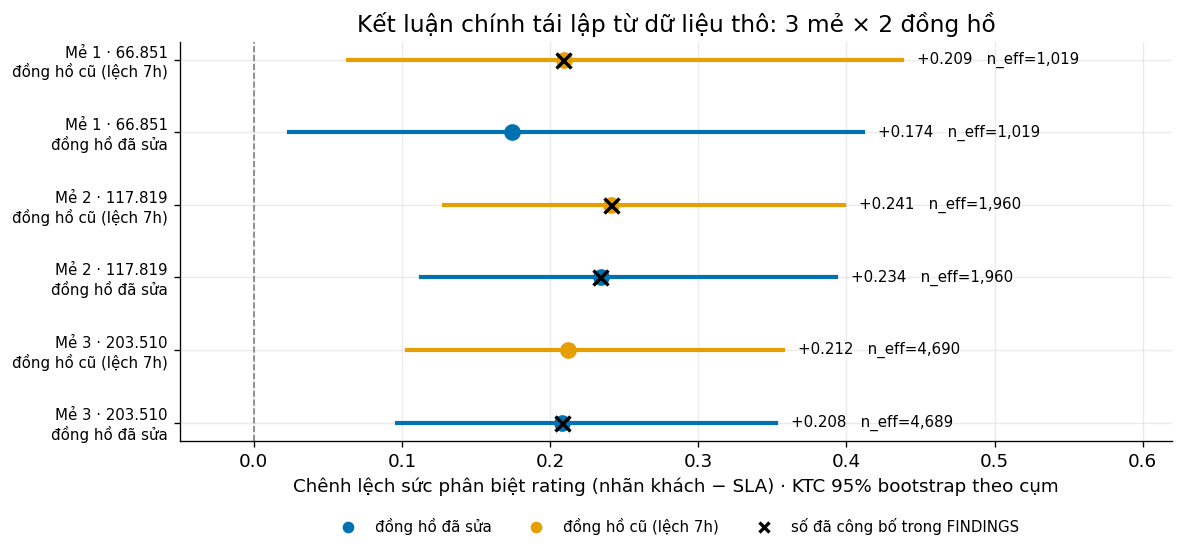

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.8))
labels = [f"{r['mẻ']}\n{r['đồng hồ']}" for _, r in forest.iterrows()]
y = np.arange(len(forest))[::-1]
for (_, r), yi in zip(forest.iterrows(), y):
    color = PALETTE[0] if r["đồng hồ"] == "đồng hồ đã sửa" else PALETTE[1]
    ax.plot([r["KTC thấp"], r["KTC cao"]], [yi, yi], color=color, lw=2.5)
    ax.plot(r["ước lượng"], yi, "o", color=color, ms=9)
    ax.text(r["KTC cao"] + 0.01, yi, f"{r['ước lượng']:+.3f}   n_eff={r['n_eff']:,}", va="center", fontsize=9)
    if not np.isnan(r["đã công bố"]):
        ax.plot(r["đã công bố"], yi, marker="x", color="black", ms=9, mew=2)
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlim(-0.05, 0.62)
ax.set_xlabel("Chênh lệch sức phân biệt rating (nhãn khách − SLA) · KTC 95% bootstrap theo cụm")
ax.set_title("Kết luận chính tái lập từ dữ liệu thô: 3 mẻ × 2 đồng hồ")
ax.plot([], [], "o", color=PALETTE[0], label="đồng hồ đã sửa")
ax.plot([], [], "o", color=PALETTE[1], label="đồng hồ cũ (lệch 7h)")
ax.plot([], [], "x", color="black", mew=2, label="số đã công bố trong FINDINGS")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, fontsize=9, frameon=False)
fig.tight_layout()
save_fig(fig, "A01_forest_tai_lap.png")
plt.show()

**Đọc kết quả.** Dấu × (số đã công bố) nằm đè lên chấm tính lại ở cả 4 ô → **không có số nào trong tài liệu bị chép
sai**. Cả 6 KTC đều nằm hẳn bên phải số 0: kết luận không phụ thuộc mẻ dữ liệu nào hay đồng hồ nào. Mẻ 1 với đồng hồ
đã sửa (+0,17) là ô duy nhất chưa từng được báo cáo — và nó vẫn dương, KTC vẫn không chứa 0.

## 3. Một API, hai đồng hồ — đo trực tiếp, không giả định

Tiki trả `created_at` (lúc viết review) dạng **epoch UTC**, và `review_created_date` (cũng lúc viết review) dạng
**chuỗi giờ Việt Nam**. Cùng một sự kiện, hai cách ghi → hiệu của chúng đo trực tiếp độ lệch giữa hai đồng hồ.
Nếu hiệu là một hằng số với phương sai 0 thì đó là quy ước múi giờ, không phải nhiễu.

In [6]:
from src.evaluate.lead_anomaly import clock_alignment

raw3 = pd.read_parquet("data/raw/tiki_reviews.parquet")
offset = clock_alignment(raw3)
print(f"n = {offset.notna().sum():,} review · trung bình {offset.mean():.4f} h · độ lệch chuẩn {offset.std():.6f} h · "
      f"min {offset.min():.4f} h · max {offset.max():.4f} h · số giá trị khác nhau: {offset.round(6).nunique()}")

a = df[df["is_analysable"]]
w, lead = a["weight"].to_numpy(float), a["lead_days"].to_numpy(float)
before = lead + 7 / 24  # code cũ: trừ thẳng epoch UTC vào chuỗi giờ VN → mọi lead time dư 7 giờ
qs = {"p25": 0.25, "trung vị": 0.50, "p75": 0.75, "p90": 0.90}
tz = pd.DataFrame({
    "trước khi sửa": [weighted_quantile(before, w, q) for q in qs.values()],
    "sau khi sửa": [weighted_quantile(lead, w, q) for q in qs.values()],
}, index=list(qs))
tz.loc["% vượt SLA 5 ngày"] = [weighted_proportion(before > 5, w) * 100, weighted_proportion(lead > 5, w) * 100]
tz["chênh"] = tz["trước khi sửa"] - tz["sau khi sửa"]
display(tz)

n = 200,307 review · trung bình 7.0000 h · độ lệch chuẩn 0.000000 h · min 7.0000 h · max 7.0000 h · số giá trị khác nhau: 1


,trước khi sửa,sau khi sửa,chênh
p25,0.9424,0.6508,0.2917
trung vị,1.5500,1.2584,0.2917
p75,2.9248,2.6331,0.2917
p90,4.6228,4.3311,0.2917
% vượt SLA 5 ngày,8.4499,7.1205,1.3294


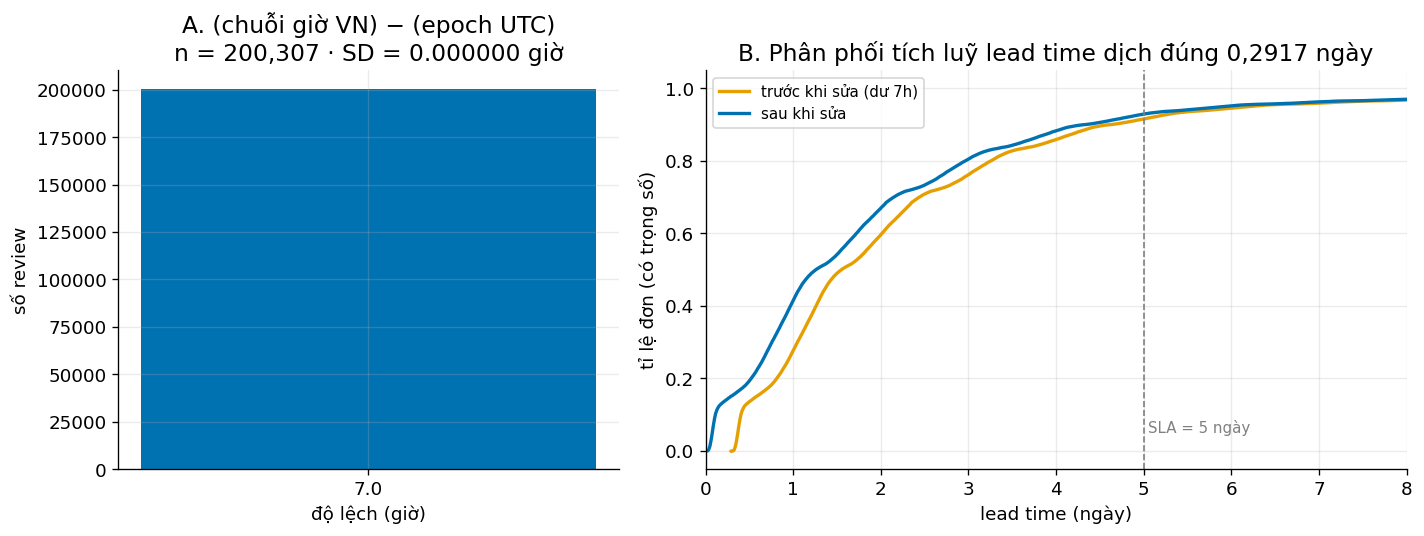

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1, 1.4]})
counts = offset.round(4).value_counts().sort_index()
ax1.bar(counts.index.astype(str), counts.values, color=PALETTE[0])
ax1.set_title(f"A. (chuỗi giờ VN) − (epoch UTC)\nn = {offset.notna().sum():,} · SD = {offset.std():.6f} giờ")
ax1.set_xlabel("độ lệch (giờ)")
ax1.set_ylabel("số review")

grid = np.linspace(0, 8, 400)
for series, name, color in ((before, "trước khi sửa (dư 7h)", PALETTE[1]), (lead, "sau khi sửa", PALETTE[0])):
    order = np.argsort(series)
    cdf = np.cumsum(w[order]) / w.sum()
    ax2.plot(series[order], cdf, color=color, lw=2, label=name)
ax2.axvline(5, color="grey", ls="--", lw=1)
ax2.text(5.05, 0.05, "SLA = 5 ngày", fontsize=9, color="grey")
ax2.set_xlim(0, 8)
ax2.set_xlabel("lead time (ngày)")
ax2.set_ylabel("tỉ lệ đơn (có trọng số)")
ax2.set_title("B. Phân phối tích luỹ lead time dịch đúng 0,2917 ngày")
ax2.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, "A02_hai_dong_ho.png")
plt.show()

**Đọc kết quả.** Hơn 200 nghìn review cho **đúng một giá trị** 7,0000 giờ, độ lệch chuẩn 0 — không thể là nhiễu.
Code cũ vì vậy cộng dư đúng 7 giờ (0,2917 ngày) vào *mọi* lead time: trung vị bị phồng từ 1,26 lên 1,55 ngày và
tỉ lệ vượt SLA bị thổi lên. Đây là lỗi **im lặng** — không làm gãy dòng code nào — và chỉ lộ ra nhờ một phép đo
đối chiếu hai trường cùng mô tả một sự kiện. `tests/test_clean.py` khoá hành vi này lại
(đặt và giao cùng thời điểm ⇒ `lead_days` phải bằng 0).

## 4. Ngưỡng SLA 5 ngày có tuỳ tiện không? — quét 3 → 7 ngày

Ngưỡng 5 ngày lấy từ SLA công bố site-wide của Tiki (xử lý 0–1 ngày + vận chuyển 1–4 ngày). Câu hỏi hiển nhiên nhất
của hội đồng: *"nếu chọn ngưỡng khác thì kết luận còn không?"*. `compute_gap()` nhận `sla_days` làm tham số, nên
chạy lại đúng kết luận chính ở 5 ngưỡng, **có KTC bootstrap** ở từng ngưỡng.

,% đơn vượt SLA (quần thể),chênh lệch,KTC thấp,KTC cao,n_eff
ngưỡng SLA (ngày),,,,,
3,19.5217,0.2372,0.1397,0.3771,4689
4,11.7129,0.2001,0.0969,0.3394,4689
5,7.1205,0.2082,0.0966,0.3525,4689
6,4.8453,0.1804,0.0489,0.3475,4689
7,3.7419,0.1558,0.0083,0.3307,4689


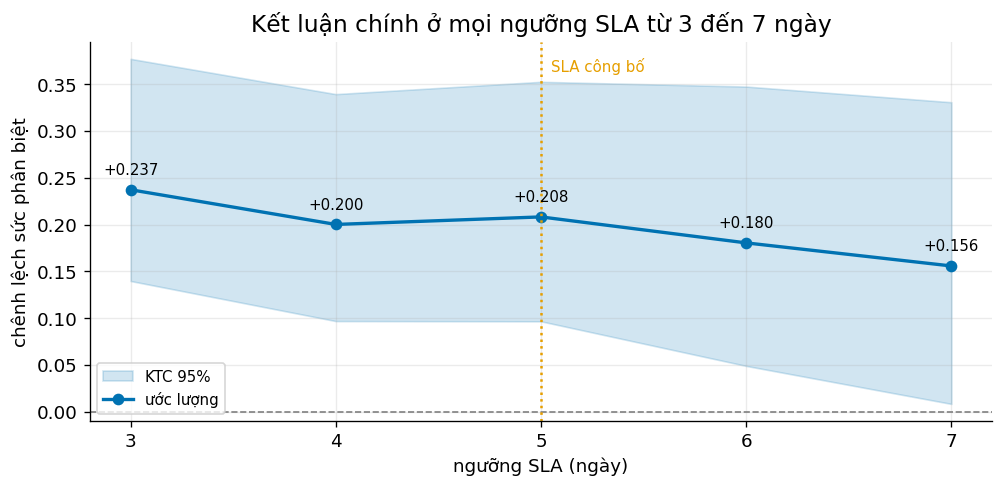

In [8]:
from src.clean.reviews import compute_gap

rows = []
for s in (3, 4, 5, 6, 7):
    d = compute_gap(df, sla_days=s)
    a_s = d[d["is_analysable"]]
    e = cluster_bootstrap(labelled_subset(d), _power_gap, n_boot=N_BOOT, seed=SEED)
    rows.append({"ngưỡng SLA (ngày)": s,
                 "% đơn vượt SLA (quần thể)": weighted_proportion(a_s["sla_breach"].astype(bool).to_numpy(),
                                                                  a_s["weight"].to_numpy(float)) * 100,
                 "chênh lệch": e.value, "KTC thấp": e.lo, "KTC cao": e.hi, "n_eff": round(e.n_eff)})
sla_sweep = pd.DataFrame(rows).set_index("ngưỡng SLA (ngày)")
display(sla_sweep)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = sla_sweep.index.to_numpy()
ax.fill_between(x, sla_sweep["KTC thấp"], sla_sweep["KTC cao"], color=PALETTE[0], alpha=0.18, label="KTC 95%")
ax.plot(x, sla_sweep["chênh lệch"], "o-", color=PALETTE[0], lw=2, label="ước lượng")
for xi, v in zip(x, sla_sweep["chênh lệch"]):
    ax.annotate(f"{v:+.3f}", (xi, v), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9)
ax.axhline(0, color="grey", ls="--", lw=1)
ax.axvline(5, color=PALETTE[1], ls=":", lw=1.5)
ax.text(5.05, ax.get_ylim()[1] * 0.92, "SLA công bố", color=PALETTE[1], fontsize=9)
ax.set_xticks(x)
ax.set_xlabel("ngưỡng SLA (ngày)")
ax.set_ylabel("chênh lệch sức phân biệt")
ax.set_title("Kết luận chính ở mọi ngưỡng SLA từ 3 đến 7 ngày")
ax.legend(fontsize=9, loc="lower left")
fig.tight_layout()
save_fig(fig, "A03_nguong_sla.png")
plt.show()

**Đọc kết quả.** Ngưỡng càng chặt thì càng nhiều đơn bị coi là "vượt SLA" (từ ~3,7% ở 7 ngày lên ~19,5% ở 3 ngày),
nhưng chênh lệch **dương ở cả 5 ngưỡng** và không KTC nào chứa 0 — kết luận không phải hệ quả của việc chọn đúng con
số 5. Nói cho đủ: ngưỡng càng lỏng thì chỉ báo SLA bám rating tốt hơn một chút (nhóm "vượt" chỉ còn các đơn thật sự
rất trễ), nên khoảng cách thu hẹp; ở **7 ngày cận dưới KTC chỉ còn ~0,01 — sát ranh giới**. Đây là giới hạn của phép
thử, không phải điểm yếu cần giấu: ở mọi ngưỡng mà một sàn TMĐT có thể công bố thực tế (3–5 ngày), kết luận vững.

## 5. Năm 2021 (giãn cách) có bóp méo kết luận không?

Có ý kiến đề xuất cắt bỏ 2021 vì tỉ lệ vượt SLA năm đó tới 16,75%. Trước khi cắt, xem nhãn khách nằm ở năm nào:

In [9]:
year_all = df.loc[df["is_analysable"], "review_ts"].dt.year
year_lab = lab["review_ts"].dt.year
by_year = pd.DataFrame({"review phân tích được": year_all.value_counts(),
                        "review có nhãn khách": year_lab.value_counts()}).fillna(0).astype(int).sort_index()
display(by_year.T)
print(f"Review có nhãn nằm ở 2023+: {int((year_lab >= 2023).sum()):,}/{len(year_lab):,}")

yr = df["review_ts"].dt.year
epochs = {"toàn mẫu": yr.notna(), "bỏ 2021": yr != 2021, "2022+": yr >= 2022, "2023+": yr >= 2023}
display(pd.Series({k: _power_gap(labelled_subset(df[m])) for k, m in epochs.items()},
                  name="chênh lệch sức phân biệt").to_frame())

review_ts,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
review phân tích được,3,46,67,439,887,3269,18458,52584,54829,26591,18369,14458,8355
review có nhãn khách,0,0,0,0,0,0,0,0,0,4529,5117,3936,2234


Review có nhãn nằm ở 2023+: 15,816/15,816


,chênh lệch sức phân biệt
toàn mẫu,0.2082
bỏ 2021,0.2082
2022+,0.2082
2023+,0.2082


**Đọc kết quả.** Trường `delivery_rating` chỉ xuất hiện từ 2023, nên **gần như mọi review có nhãn nằm ở 2023–2026**.
Cắt 2021, 2022 hay mọi năm trước 2023 đều cho **đúng cùng một con số** — đây không phải lỗi code mà là bằng chứng:
kết luận chính *chưa bao giờ dùng* dữ liệu 2021. Ngược lại, cắt 2021 sẽ xoá ~60% số ca vượt SLA mà phần mô hình cần
(TASKS §1.1). Quyết định D1 — giữ toàn mẫu, báo cáo theo năm — có căn cứ.

## 6. MNAR — 74% review trong kỷ nguyên có nhãn lại **không** có nhãn

### 6.1 Thiếu nhãn gồm HAI cơ chế, không phải một

In [10]:
from src.evaluate import mnar_sensitivity as mn

d_mnar = mn.prepare(df)
display(mn.coverage_by_year(d_mnar))
decomp = pd.DataFrame(mn.selection_decomposition(d_mnar)).T
decomp.index = decomp.index.str.replace("_", " ")
display(decomp)

,n,có_nhãn,% có nhãn
nam,,,
2017,439,0,0.0000
2018,887,0,0.0000
2019,3269,0,0.0000
2020,18458,0,0.0000
2021,52584,0,0.0000
2022,54829,0,0.0000
2023,26591,4529,17.0300
2024,18369,5117,27.8600
2025,14458,3936,27.2200


,n,rating,lead_tb,vượt_sla_%
gộp có nhãn,"15,816.0000",4.9034,1.3464,1.9082
gộp không nhãn,"182,539.0000",4.7725,2.2970,7.6340
kỷ nguyên có nhãn,"15,816.0000",4.9034,1.3464,1.9082
kỷ nguyên không nhãn,"51,957.0000",4.8759,1.4821,2.4076
trước kỷ nguyên,"130,582.0000",4.7314,2.6208,9.7103


* **Thiếu do thiết kế** (2017–2022, độ phủ đúng 0%): trường chưa tồn tại. Không giả định nào "sửa" được — nhóm đó
  chưa bao giờ có cơ hội mang nhãn. Kết luận chính vì vậy chỉ khái quát cho **kỷ nguyên 2023–2026**.
* **Chọn lọc thật** (trong 2023+): so gộp thì nhóm không nhãn vượt SLA gấp 4×, nhưng so **cùng kỷ nguyên** chỉ 1,3× —
  phần lớn khác biệt là hiệu ứng thời kỳ, không phải chọn lọc.

### 6.2 Chặn Manski — không cần giả định, và (như dự đoán) quá rộng

In [11]:
bounds = mn.manski_bounds(d_mnar)
display(pd.Series(bounds, name="giá trị").to_frame())

,giá trị
n_era,"67,773.0000"
n_labelled,"15,816.0000"
n_unlabelled,"51,957.0000"
weighted_labelled_pct,25.7329
lower_pct,0.4824
upper_pct,74.7495
n_eff,"20,076.0980"


Chặn Manski cho tỉ lệ "khách nói trễ" trong 2023+: từ ~0,5% (mọi review không nhãn đều "đúng hẹn") tới ~75% (mọi
review không nhãn đều "trễ"). Khoảng này **vô dụng** — đúng như dự đoán trước khi chạy, vì 74% dòng không có nhãn.
Biết một chặn không siết được gì cũng là kết quả: nó buộc ta phải dùng phép thử có tham số ở §6.3.

### 6.3 Quét điểm gãy θ — kết luận chịu được bao nhiêu "mất thông tin"?

Với mỗi review **không nhãn**, gán xác suất "khách sẽ nói trễ":

$$p_i(\theta) = \theta \cdot p_{\text{MAR}}(\text{rating}_i, \text{vượt SLA}_i) + (1-\theta)\cdot \bar p$$

* $p_{\text{MAR}}$ ước lượng từ nhóm có nhãn, trên từng ô (rating × vượt SLA); $\bar p$ là tỉ lệ "trễ" chung.
* **θ = 1**: nhóm không nhãn cư xử như nhóm có nhãn (MAR). **θ = 0**: nhãn *không mang chút thông tin nào* về rating.
* Mỗi dòng góp trọng số phân đoạn $w\,p$ vào nhóm "trễ" và $w(1-p)$ vào nhóm "đúng hẹn" — tính đúng tuyệt đối,
  không cần mô phỏng.

**θ\*** = mức θ mà tại đó kết luận chạm 0.

θ = 1 (MAR): +0.2217 · θ = 0: -0.0114 · θ* = 0.0468
→ Kết luận chỉ sụp nếu nhãn khách trong nhóm không nhãn mất hơn 95.3% thông tin so với MAR.



Tự kiểm A3 — chạy theta_scan trên riêng nhóm có nhãn, ép p = nhãn thật:
  FINDINGS §4 = +0.208200 · theta_scan = +0.208188 · sai khác -0.000012 ✅


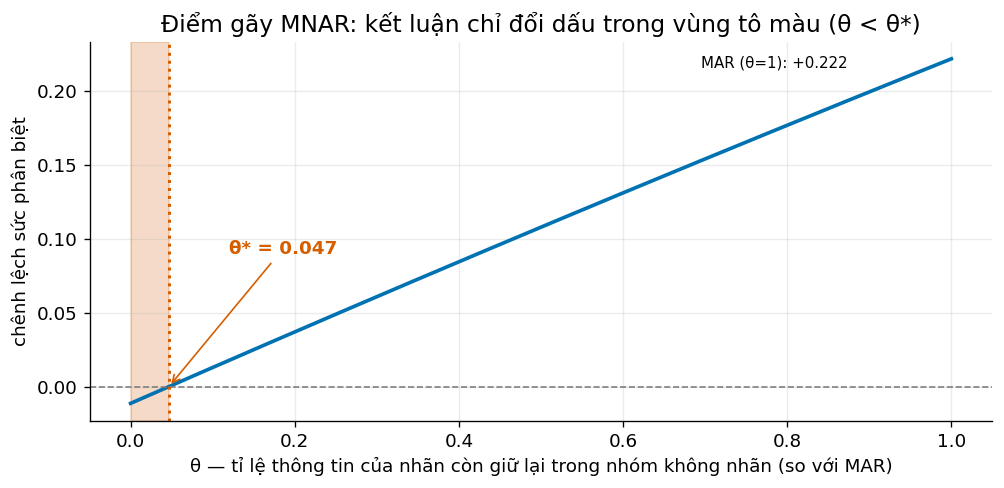

In [12]:
era = d_mnar[d_mnar["nam"] >= mn.LABEL_ERA_START]
scan = mn.theta_scan(era, theta_step=0.001)
theta_star = mn.find_theta_star(scan)
print(f"θ = 1 (MAR): {scan['estimate'].iloc[-1]:+.4f} · θ = 0: {scan['estimate'].iloc[0]:+.4f} · θ* = {theta_star:.4f}")
print(f"→ Kết luận chỉ sụp nếu nhãn khách trong nhóm không nhãn mất hơn {(1 - theta_star) * 100:.1f}% thông tin so với MAR.")

check = mn.a3_self_check(era[era["customer_says_late"].notna()])
print(f"\nTự kiểm A3 — chạy theta_scan trên riêng nhóm có nhãn, ép p = nhãn thật:")
print(f"  FINDINGS §4 = {check['target']:+.6f} · theta_scan = {check['observed']:+.6f} · sai khác {check['difference']:+.6f} ✅")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(scan["theta"], scan["estimate"], color=PALETTE[0], lw=2.2)
ax.axhline(0, color="grey", ls="--", lw=1)
ax.axvline(theta_star, color=PALETTE[5], ls=":", lw=1.8)
ax.annotate(f"θ* = {theta_star:.3f}", (theta_star, 0), textcoords="data", xytext=(0.12, 0.09),
            color=PALETTE[5], fontsize=11, fontweight="bold", arrowprops=dict(arrowstyle="->", color=PALETTE[5]))
ax.annotate(f"MAR (θ=1): {scan['estimate'].iloc[-1]:+.3f}", (1, scan["estimate"].iloc[-1]),
            textcoords="offset points", xytext=(-150, -5), fontsize=9)
ax.axvspan(0, theta_star, color=PALETTE[5], alpha=0.22)
ax.set_xlabel("θ — tỉ lệ thông tin của nhãn còn giữ lại trong nhóm không nhãn (so với MAR)")
ax.set_ylabel("chênh lệch sức phân biệt")
ax.set_title("Điểm gãy MNAR: kết luận chỉ đổi dấu trong vùng tô màu (θ < θ*)")
fig.tight_layout()
save_fig(fig, "A04_diem_gay_theta.png")
plt.show()

**Đọc kết quả.** Kết luận giữ dương trên gần như toàn bộ dải θ và chỉ chạm 0 khi θ < θ\* ≈ 0,05 — tức là phải giả định
rằng ở 74% review không nhãn, lời khách **gần như không liên quan gì** tới rating (mất >95% thông tin so với nhóm có
nhãn). Đó là một giả định cực đoan, khó bảo vệ. Phép tự kiểm A3 tái lập đúng +0,2082 nên hàm quét θ tính đúng.

## 7. Bẫy SLA có khác nhau giữa ngành hàng / nhà bán không? — trung thực khi dữ liệu không đủ

Hai ô "bẫy" chỉ có 252 + 339 = 591 dòng cho cả 10 ngành. Xếp hạng trên vài ca mỗi ngành là xếp hạng nhiễu, nên:
gộp còn 3 nhóm ngành, và mỗi ô phải qua **cổng `n_eff ≥ 100`** mới được báo cáo.

In [13]:
from src.evaluate.category_decomposition import category_stats

display(category_stats(df)[["category_name", "n", "n_eff", "n_in_sla_late", "n_eff_in_sla_late",
                            "n_breach_ontime", "n_eff_breach_ontime", "status"]])

,category_name,n,n_eff,n_in_sla_late,n_eff_in_sla_late,n_breach_ontime,n_eff_breach_ontime,status
0,Nhà cửa – Gia dụng,8414,"2,541.1025",158,45.9576,192,61.3254,⚠️ KHÔNG ĐỦ DỮ LIỆU
1,Cá nhân – Gia đình,5053,"2,288.4289",71,20.4984,92,53.7721,⚠️ KHÔNG ĐỦ DỮ LIỆU
2,Sách – Thể thao – Công nghệ,2349,646.6787,23,13.4916,55,35.5428,⚠️ KHÔNG ĐỦ DỮ LIỆU


In [14]:
from src.models.experiments import load_frame
from src.models.diagnostics import sla_trap_table, sla_trap_difference

labelled_frame = load_frame().query("has_customer_label")
display(sla_trap_table(labelled_frame).T)
for rate in ("báo_động_giả", "bỏ_sót"):
    print(sla_trap_difference(labelled_frame, rate, n_boot=1000))

nhóm,Bên thứ ba,Tiki Trading
n,4243,11573
n_eff,"2,848.0241","3,584.5668"
trong SLA · khách đúng hẹn,4033,11127
trong SLA · khách trễ,53,199
vượt SLA · khách đúng hẹn,136,203
vượt SLA · khách trễ,21,44
báo_động_giả,0.8883,0.8208
n_eff_báo_động_giả,101.0586,78.6319
cờ_báo_động_giả,,⚠️ MONG MANH
bỏ_sót,0.7324,0.8479


Δ báo_động_giả (Tiki Trading − bên thứ ba): -0.0675 [-0.1759, 0.0225] (95% CI, n=15,816, n_eff=4689, cụm=1,916)


Δ bỏ_sót (Tiki Trading − bên thứ ba): 0.1155 [-0.0214, 0.2422] (95% CI, n=15,816, n_eff=4689, cụm=1,916)


**Đọc kết quả.** Cả 3 nhóm ngành đều **không qua cổng `n_eff`** ở ô "khách nói trễ nhưng trong SLA". Tiki Trading và
nhà bán bên thứ ba có tỉ lệ bẫy trông khác nhau, nhưng **KTC của cả hai chênh lệch đều chứa 0**. Kết luận trung thực:
*bẫy SLA tồn tại ở mọi nhóm, dữ liệu hiện có không đủ để nói nhóm nào tệ hơn* — không trích như một phát hiện.

## 8. Loại 1.799 dòng `lead_days` âm có cắt mất khách bất mãn không?

Các dòng này được **gắn cờ, không xoá** (nguyên nhân: `purchased_at` ghi lần mua *gần nhất*, khách mua lại sau khi đã
review — FINDINGS §6.2). Câu hỏi: loại chúng khỏi phân tích lead time có làm lệch kết luận không?

In [15]:
from src.evaluate.lead_anomaly import prepare as prepare_anomaly, weighted_impact

imp = weighted_impact(prepare_anomaly(df))
impact = pd.DataFrame({
    "đếm thô ❌": [imp["neg_rating_tb_thô"], imp["rest_rating_tb_thô"], imp["neg_pct_1sao_thô"], imp["rest_pct_1sao_thô"]],
    "có trọng số ✅": [imp["neg_rating_tb"], imp["rest_rating_tb"], imp["neg_pct_1sao"], imp["rest_pct_1sao"]],
}, index=["rating TB · dòng âm", "rating TB · dòng còn lại", "% 1 sao · dòng âm", "% 1 sao · dòng còn lại"])
display(impact)
print(f"Nhóm bị loại chiếm {imp['pct_quần_thể']:.2f}% quần thể (có trọng số).")

,đếm thô ❌,có trọng số ✅
rating TB · dòng âm,4.4786,4.7696
rating TB · dòng còn lại,4.5600,4.7812
% 1 sao · dòng âm,6.9483,2.9528
% 1 sao · dòng còn lại,3.1377,1.4587


Nhóm bị loại chiếm 0.97% quần thể (có trọng số).


**Đọc kết quả.** Đếm thô nói nhóm bị loại có tỉ lệ 1 sao **gấp đôi** — nhưng đó là ảo ảnh của mẫu phân tầng (tầng sao thấp
bị vét cạn nên sao thấp bị phóng đại trong *mọi* nhóm con). Nhân trọng số thì rating trung bình gần như bằng nhau và nhóm
này chỉ chiếm ~1% quần thể. Loại nó ra không làm lệch kết luận.

## 9. Tổng kết — kết luận chính đã đi qua những phép thử nào

| Tầng | Phép thử | Kết quả |
|---|---|---|
| 1 · Data contract | 22 phép kiểm tự động (`00_data_quality_B16_report`) | 22/22 đạt |
| 2 · Reproducibility | §2 — chạy lại pipeline trên 3 mẻ thô lưu trữ | 4/4 số đã công bố tái lập đúng |
| 5 · Significance | §1 — bootstrap theo cụm sản phẩm | KTC [0,097 · 0,353] không chứa 0 |
| 8 · Robustness | §4 ngưỡng SLA 3–7 ngày · §5 bỏ năm · §8 dòng lỗi | dương ở mọi biến thể (sát 0 ở ngưỡng 7 ngày) |
| 9 · Sanity check | §3 — đo độ lệch hai đồng hồ trên >200k review | đúng 7,0000 giờ, SD = 0 |
| MNAR | §6 — Manski + quét điểm gãy θ | chỉ sụp nếu nhãn mất >95% thông tin |
| 7 · Error analysis | §7 — ngành hàng, Tiki Trading vs bên thứ ba | không đủ dữ liệu → không kết luận |

Tầng 3 (leakage), 4 (baseline ladder), 6 (calibration) thuộc phần mô hình — xem `03_modeling.ipynb`, nơi kết luận
này được **chứng minh lần hai bằng một phương pháp độc lập** (sức dự đoán PR-AUC, C9).